In [212]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [390]:
def distance_from_closest_value(x, values_taken):
    if not isinstance(x, np.ndarray):
        return min(map(lambda val: abs(val - x), values_taken))
    else:
        return np.array([distance_from_closest_value(xi, values_taken) for xi in  x])


def score(score_function, values_sorted):
    return lambda x: score_function(distance_from_closest_value(x, values_sorted))

In [391]:
def get_distances(my_range, values_taken):
    if values_taken == []: return []
    distances = [2*(values_taken[0] - my_range[0])] #
    
    for i in range(len(values_taken)-1):
        distances.append(values_taken[i+1] - values_taken[i])
    
    distances.append(2*(my_range[-1] - values_taken[-1])) #
    return distances

def normalize_score_output(func, my_range, values_taken):
    min_value = func(0)
    max_value = func(max(map(lambda x: x/2, get_distances(my_range, values_taken)))) # x/2 because we apply the function on the distance between 2 points

    return lambda x: (x - min_value)/(max_value - min_value)

In [418]:
def plot_draw(ax, x, f, values_taken, normalize_output = True, draw_value_curves = False):
    hull = score(f, values_taken)
    
    if normalize_output:
        ax.set_ylim((0, 1))
        option_score_dev = lambda x: normalize_score_output(f, (x[0], x[-1]), values_taken)(hull(x))
        option_score_user = lambda x: 1 - option_score_dev(x)
    else: 
        ax.set_ylim((0, 10))
        option_score_dev = hull
        option_score_user = lambda x: 1 / option_score_dev(x)
        

    if draw_value_curves:
        for v in values_taken:
            g = lambda x: f(x-v)
            ax.plot(x, g(x), color='black')

    ax.plot(x, option_score_dev(x), color='green', ls='-', lw=5)
    ax.plot(x, option_score_user(x), color='red', ls='--', lw=3)
    for v in values_taken:
        ax.plot([v, v], [0, 1], color = 'blue', ls = (0, (1, 10)), lw = 2)

/tmp/ipykernel_4129322/1803333501.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


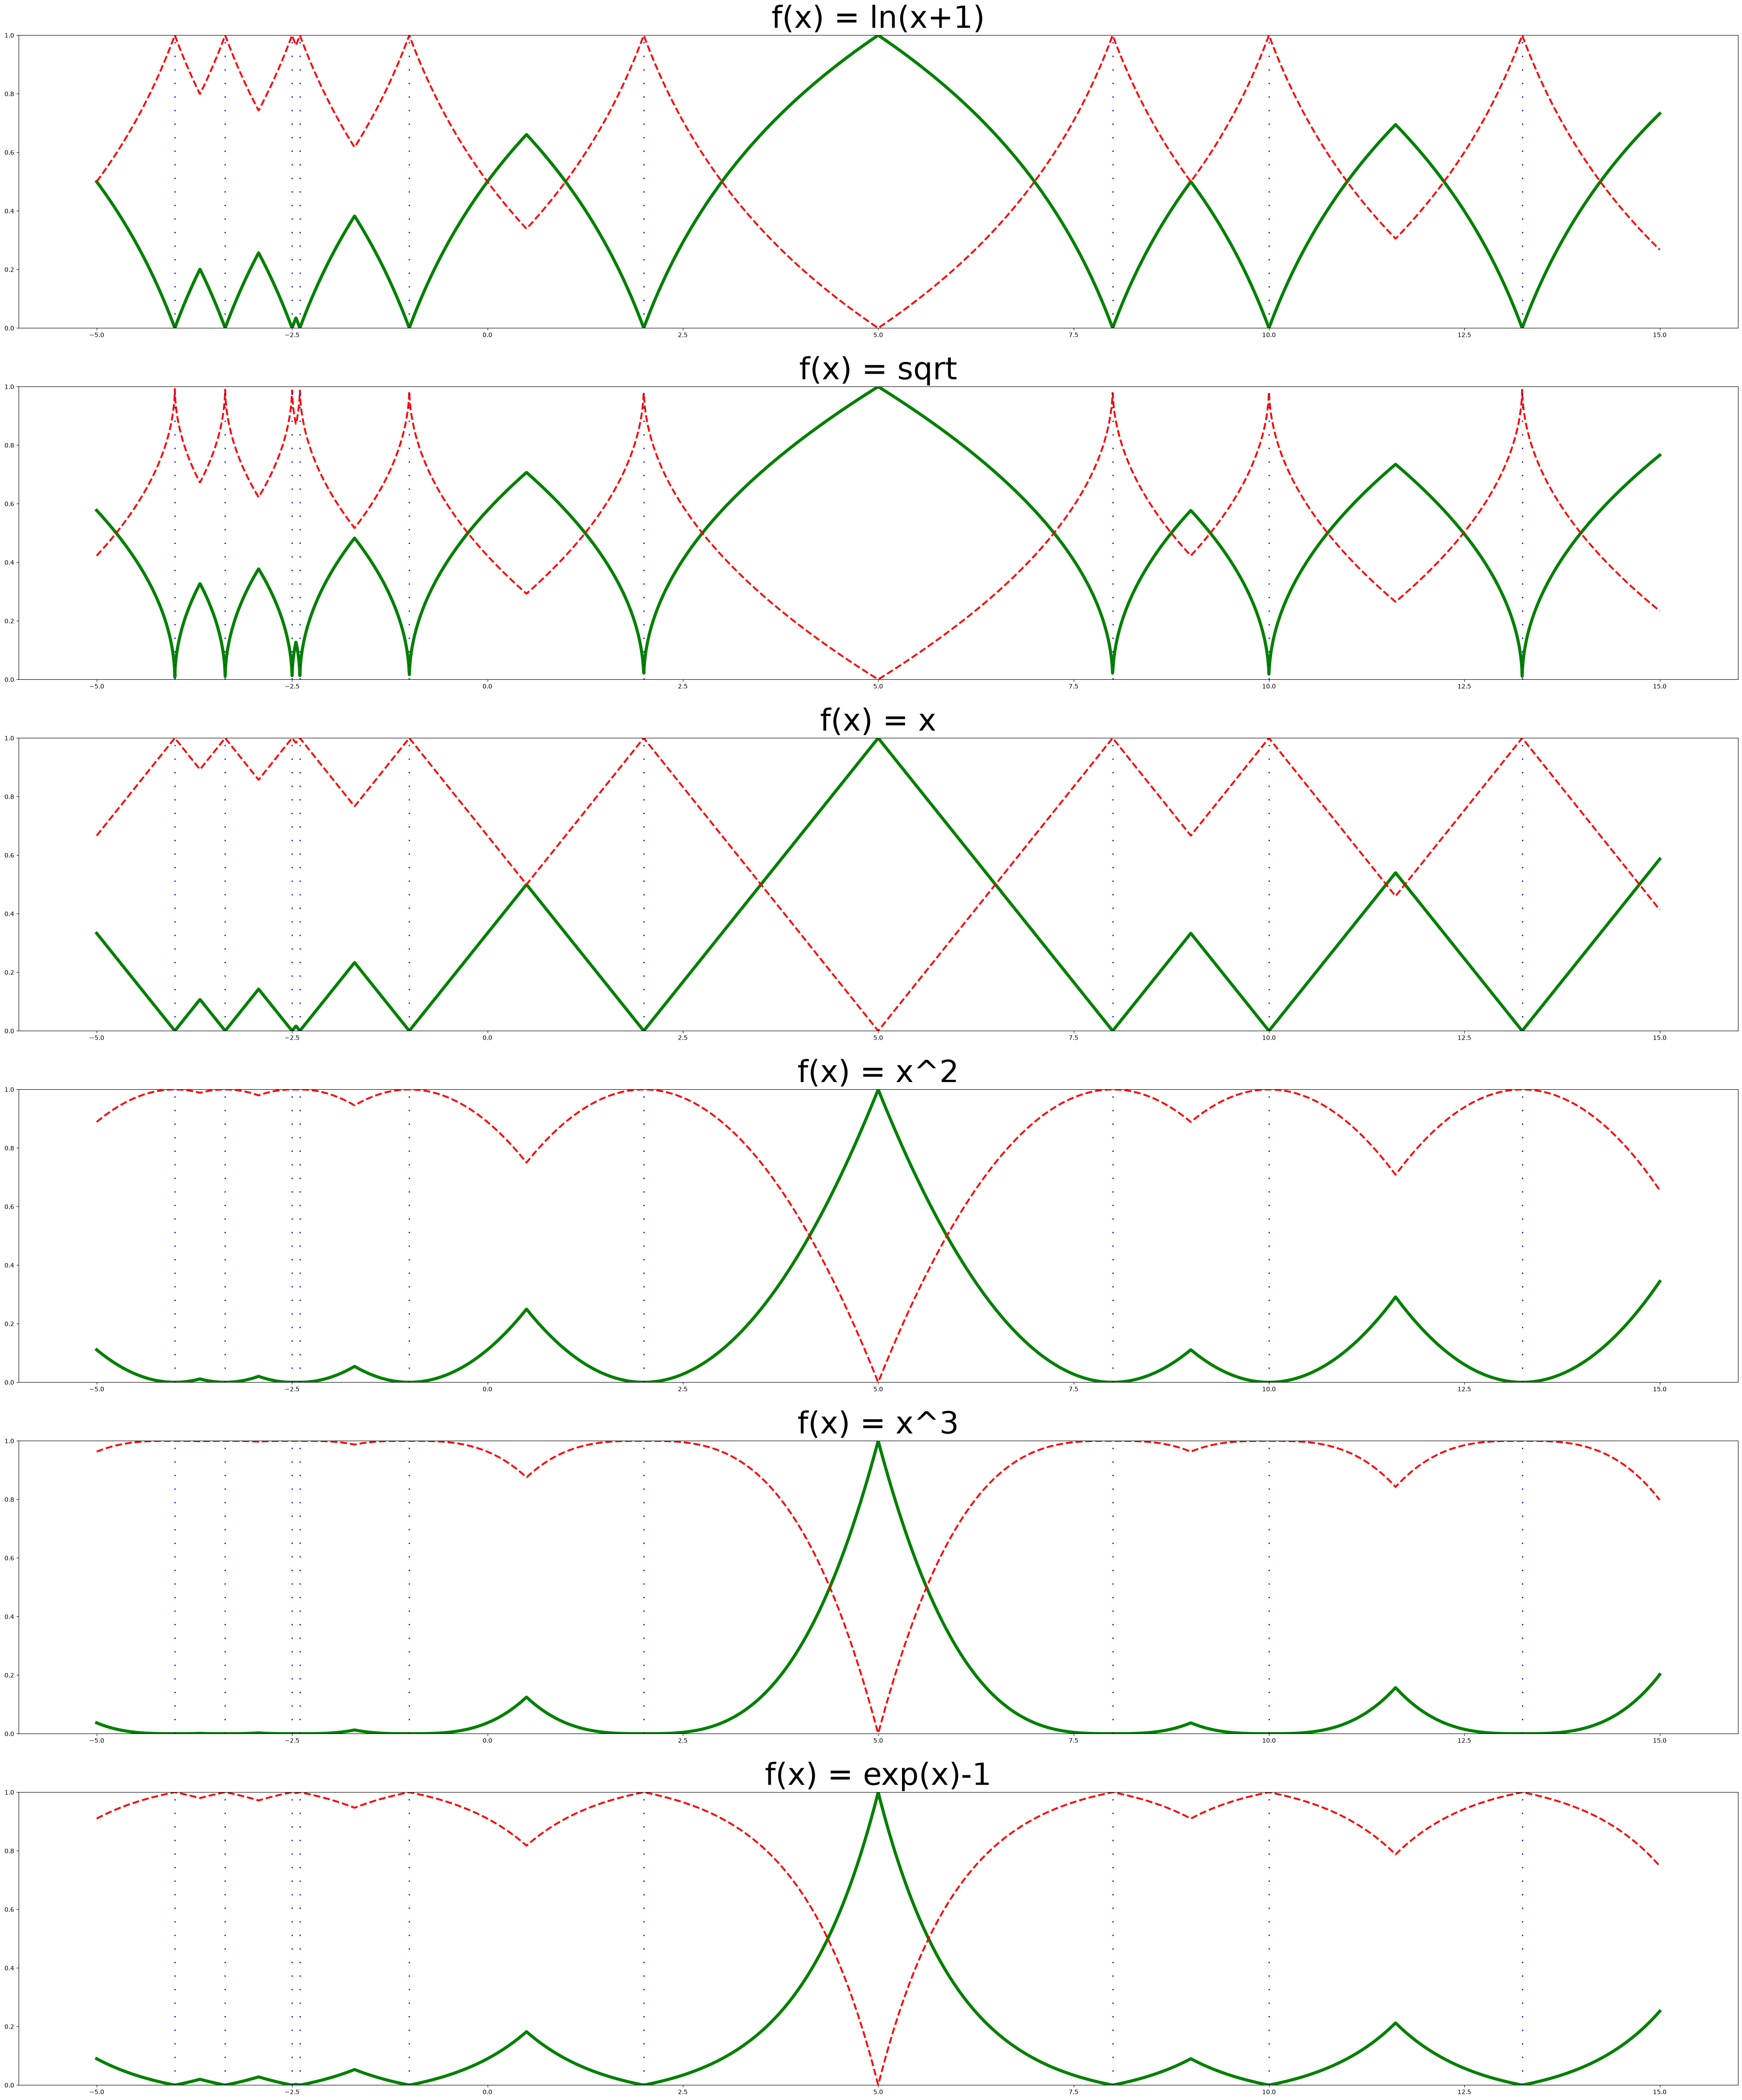

In [419]:
width = 50
height = 10
my_range = (-5, 15)
values_taken = [-4, -3.356, -2.5, -2.4, -1, 2, 8, 10, 13.24]
x = np.linspace(*my_range, 5000)
distance_functions = [lambda x : np.log(x+1), np.sqrt, lambda x: x, lambda x: x**2, lambda x: x**3, np.expm1]
functions_expression = ["ln(x+1)", "sqrt", "x", "x^2", "x^3", "exp(x)-1"]

subplots = len(distance_functions)

fig, axs = plt.subplots(subplots, 1, figsize=(width, subplots*height))
y_for_scatter = [0]*len(values_taken)

for ax, f, string in zip(axs, distance_functions, functions_expression):
    plot_draw(ax, x, f, values_taken, normalize_output=True, draw_value_curves=False)
    ax.set_title(label=f"f(x) = {string}", fontdict={'fontsize':50})
    
fig.show()